Imports

In [1]:
import numpy as np
from model.grid_init import *
from model.parameters import get_default_parameters
from model.population_growth import *
import matplotlib.pyplot as plt
from skopt import gp_minimize

The idea here is to optimize pulsed dosing. The two variables are the dose and interval. The objective being minimized is a score based on the final tumor mass (the initial tumor mass is the same), the amount of drug used and the cytotoxicity by assuming that after a certain threshold of concentration the drug becomes toxic.

Since we only optimize the dose and interval, it means the dose will be administered at a fixed point. We can assume that that point corresponds to a blood vessel, which could explain the constraint (the real explanation is that it would take forever).

Running simulation and determining the final score for the parameters

In [2]:
C_toxic = 0.3  # Cytotoxic concentration threshold

In [3]:
def run_simulation(params, time_steps):
    total_drug = 0
    cytotoxicity = 0
    density_grid, concentration_grid = initialize_density_blob(params.grid_dims, params.blob_centers, params.blob_std_dev)

    for t in range(time_steps):
        if t % round(params.dose_interval / params.dt) == 0:
            concentration_grid = add_dose(concentration_grid, params.source_concentration, params.source_positions)
            total_drug += params.dose
        concentration_grid = update_concentration_3d(concentration_grid, density_grid, params.diffusion_rate,
                                                      params.dt, params.dx, params.decay, params.beta)
        drug_effect_grid = drug_effect(concentration_grid, params.EC50, params.hill_coefficient)
        density_grid = update_density_3d(density_grid, drug_effect_grid, params.r, params.alpha, params.dt, params.dx, params.movement_rate)
        cytotoxicity += np.sum(np.maximum((concentration_grid - C_toxic)**2, 0)) * params.dt
    tumor_mass = np.sum(density_grid) * (params.dx ** 3)

    return tumor_mass,total_drug, cytotoxicity

In [4]:
def score(tumor_mass, total_drug, cytotoxicity):
    return tumor_mass + 0.4 * total_drug + 0.00008 * cytotoxicity

In [5]:
def objective_function(hyperparams):
    dose, interval = hyperparams
    params = get_default_parameters()
    params.dose = dose
    params.dose_interval = interval
    tumor_mass, total_drug, cytotoxicity = run_simulation(params, time_steps=3000)
    return score(tumor_mass, total_drug, cytotoxicity)

Defining the search space for the hyperparameters. We then use bayesian optimization using gaussian process to determine the optimal hyperparameter pair. This is nice because the simulation is pretty expensive (3 mins for just 30 points on the grid).

We then use the estimator to interpolate for other points in the grid, and we obtain a heatmap of hyperparameter space and score

In [6]:
search_space = [
    (0.1, 1.0), # Dose range
    (0.2,2.0) # Interval range
]

result = gp_minimize(objective_function, search_space, n_calls=30, random_state=42)

/Users/rayenezanina/Desktop/Project/Tumor simulation/.venv/lib/python3.14/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [0.1, 0.2] before, using random point [0.15650623937519437, 1.6589630309999077]
  warnings.warn(
/Users/rayenezanina/Desktop/Project/Tumor simulation/.venv/lib/python3.14/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [0.1, 0.2] before, using random point [0.20117167060120741, 0.9107697387822973]
  warnings.warn(


In [7]:
best_dose, best_interval = result.x
print(f"Best Dose: {best_dose}, Best Interval: {best_interval}")

Best Dose: 0.1, Best Interval: 0.2


In [8]:
model = result.models[-1]
dose_range = np.linspace(0.1, 1.0, 20)
interval_range = np.linspace(0.2, 2.0, 20)
dose_grid, interval_grid = np.meshgrid(dose_range, interval_range)
score_grid = model.predict(np.column_stack([dose_grid.ravel(), interval_grid.ravel()]))

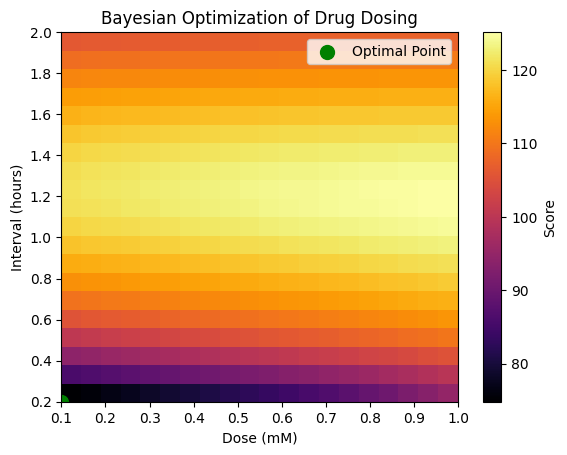

In [11]:
plt.imshow(score_grid.reshape(dose_grid.shape), extent=(0.1, 1.0, 0.2, 2.0), cmap='inferno', aspect='auto', origin='lower')
plt.colorbar(label='Score')
plt.scatter(best_dose , best_interval , c='green', s=100, label='Optimal Point')
plt.xlabel('Dose (mM)')
plt.ylabel('Interval (hours)')
plt.title('Bayesian Optimization of Drug Dosing')
plt.legend()